# Baseline Classical ML

In [1]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# ----------------------------
# SETTINGS
# ----------------------------
DATA_PATH = r"C:\Users\shanmugam\QUANTUM HACK\Epileptic Seizure Recognition.csv"
RANDOM_STATE = 42
N_PER_CLASS = 250
TRAIN_SIZE = 300
TEST_SIZE = 200
N_COMPONENTS = 12  # PCA-12

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(DATA_PATH)

# ----------------------------
# LOAD
# ----------------------------
df = pd.read_csv(DATA_PATH)

# drop unnamed columns (if any)
drop_cols = [c for c in df.columns if c.lower().startswith("unnamed")]
if drop_cols:
    df = df.drop(columns=drop_cols)

if "y" not in df.columns:
    raise ValueError("Label column 'y' not found.")

X = df.drop(columns=["y"])
y_raw = df["y"].astype(int)

# Binary labels: 1 -> seizure(1), 2..5 -> non-seizure(0)
y = (y_raw == 1).astype(int)

# ----------------------------
# BALANCE (250 seizure + 250 non-seizure)
# ----------------------------
df_bin = X.copy()
df_bin["label"] = y

df_seiz = df_bin[df_bin["label"] == 1]
df_non  = df_bin[df_bin["label"] == 0]

if len(df_seiz) < N_PER_CLASS or len(df_non) < N_PER_CLASS:
    raise ValueError(f"Not enough samples to balance: seizure={len(df_seiz)}, non={len(df_non)}")

df_bal = pd.concat([
    df_seiz.sample(n=N_PER_CLASS, random_state=RANDOM_STATE),
    df_non.sample(n=N_PER_CLASS, random_state=RANDOM_STATE)
]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

X_bal = df_bal.drop(columns=["label"]).values
y_bal = df_bal["label"].values.astype(int)

print("✅ Balanced:", X_bal.shape, "Counts:", {0:int((y_bal==0).sum()), 1:int((y_bal==1).sum())})

# ----------------------------
# SPLIT 300 / 200 (stratified)
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal,
    train_size=TRAIN_SIZE,
    test_size=TEST_SIZE,
    stratify=y_bal,
    random_state=RANDOM_STATE
)
print("✅ Split:", X_train.shape, X_test.shape)

# ----------------------------
# PREPROCESS: Standardize + PCA(12)
# ----------------------------
preprocess = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE))
])

Xtr = preprocess.fit_transform(X_train)
Xte = preprocess.transform(X_test)

print("✅ PCA-12 ready:", Xtr.shape, Xte.shape)
print("✅ PCA explained variance sum:",
      round(float(np.sum(preprocess.named_steps["pca"].explained_variance_ratio_)), 4))

✅ Balanced: (500, 178) Counts: {0: 250, 1: 250}
✅ Split: (300, 178) (200, 178)
✅ PCA-12 ready: (300, 12) (200, 12)
✅ PCA explained variance sum: 0.606


✅ Done: ExtraTrees
✅ Done: GradientBoost
✅ Done: AdaBoost
✅ Done: SVM-RBF

📌 CLASSICAL RESULTS (ONLY 4)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,TrainTime(s),TestTime(s)
0,SVM-RBF,0.945,0.958763,0.93,0.944162,0.9926,0.993011,0.019194,0.001273
1,ExtraTrees,0.940,0.948980,0.93,0.939394,0.9938,0.993679,1.006186,0.182534
2,GradientBoost,0.940,0.958333,0.92,0.938776,0.9885,0.985344,0.215354,0.001618
3,AdaBoost,0.925,0.956989,0.89,0.922280,0.9869,0.984749,0.778315,0.042684


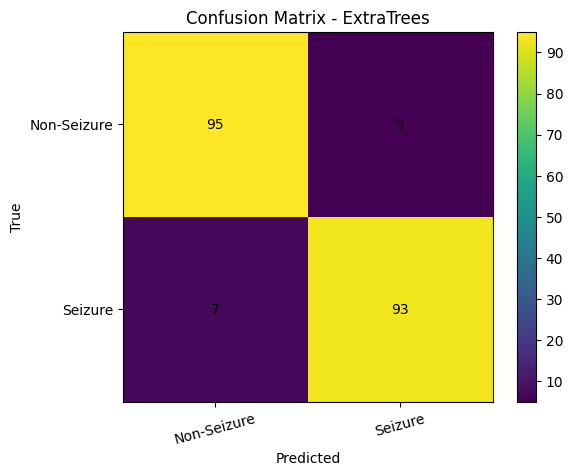

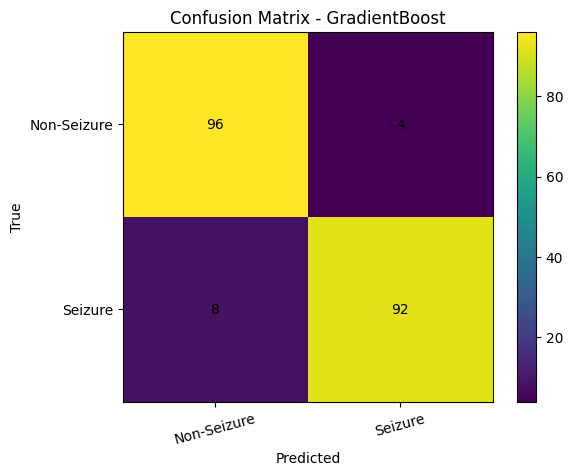

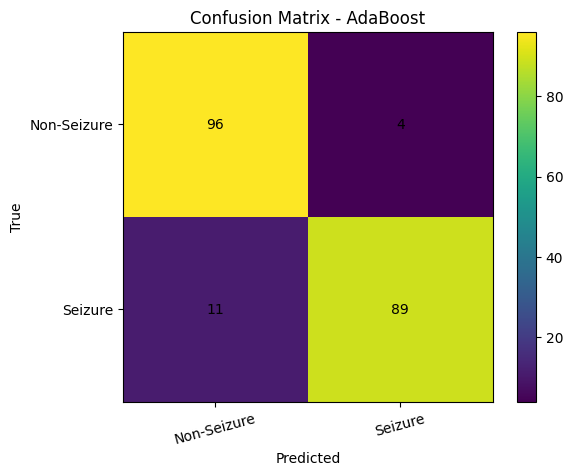

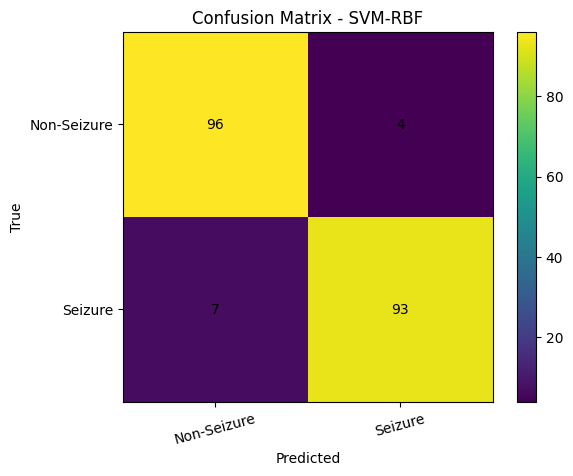

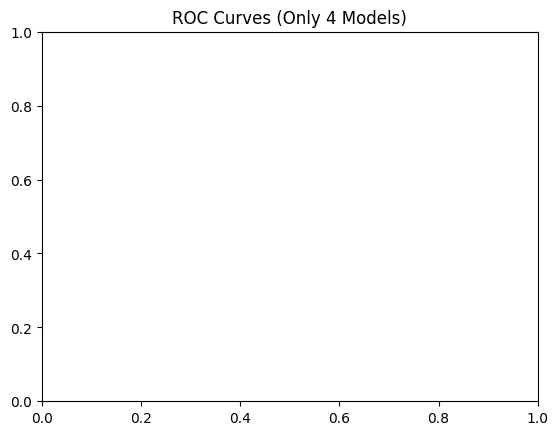

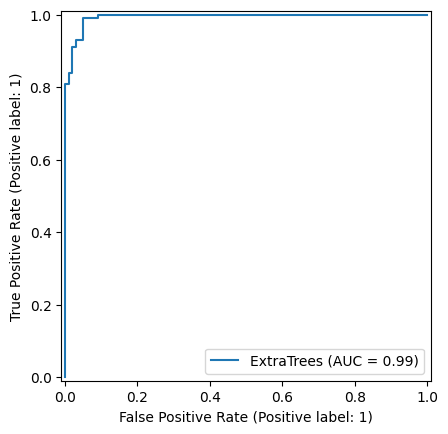

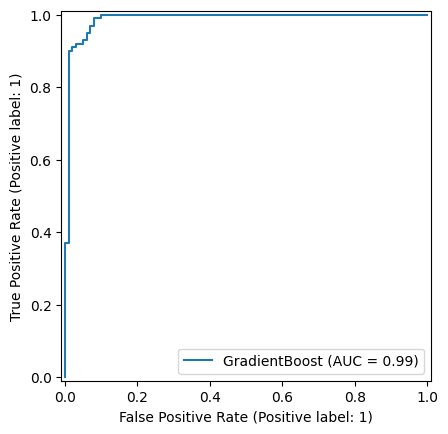

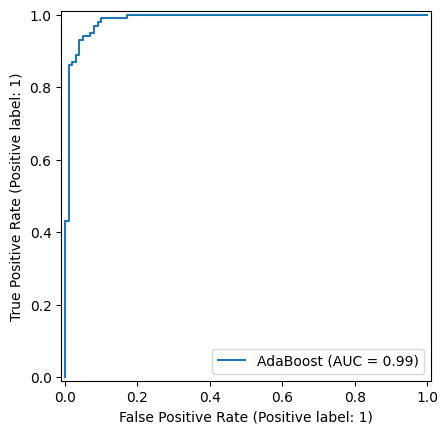

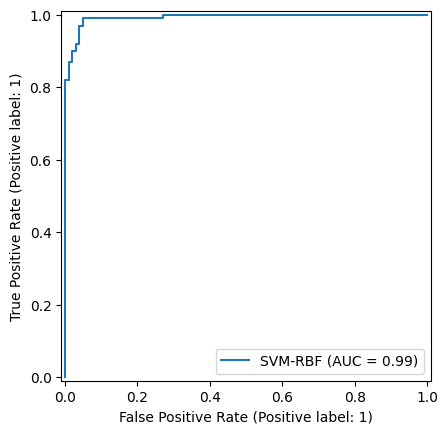

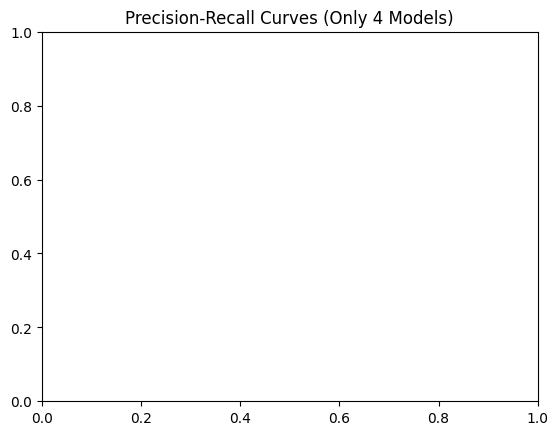

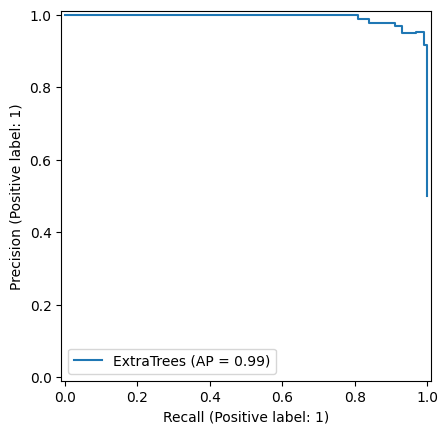

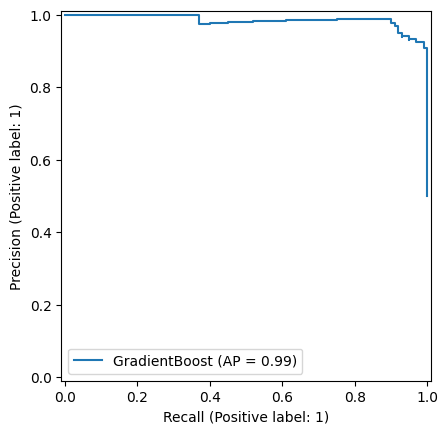

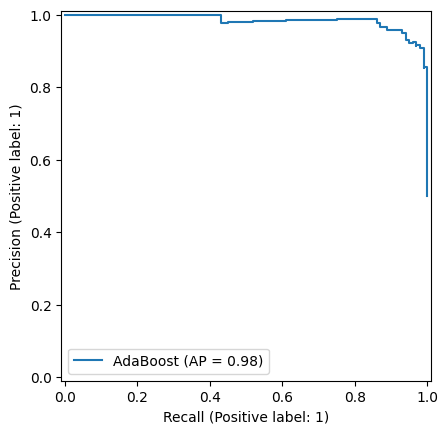

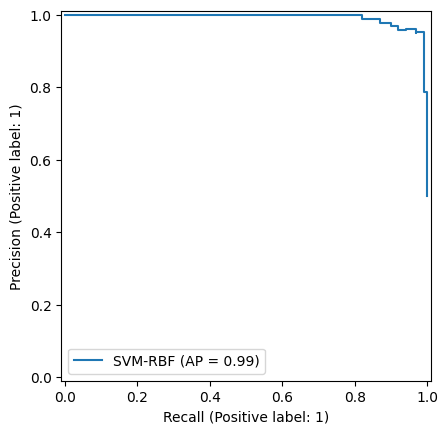

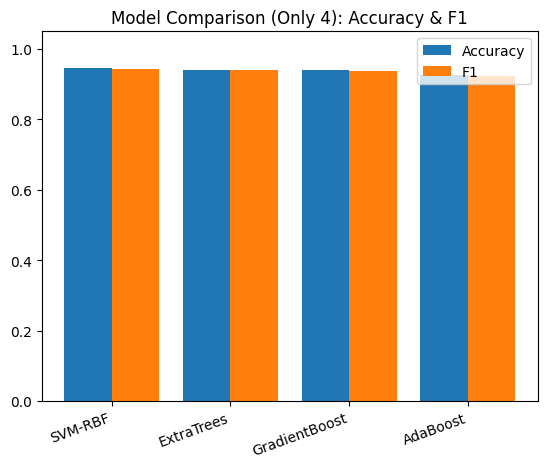

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, RocCurveDisplay, PrecisionRecallDisplay
)

from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC


def _get_scores(model, X):
    """Return continuous scores for ROC/PR."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        # normalize to [0,1] for stability (optional)
        s = (s - s.min()) / (s.max() - s.min() + 1e-12)
        return s
    # fallback
    return model.predict(X).astype(float)


def eval_model(name, model, Xtr, ytr, Xte, yte):
    t0 = time.perf_counter()
    model.fit(Xtr, ytr)
    train_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred = model.predict(Xte)
    test_time = time.perf_counter() - t0

    y_score = _get_scores(model, Xte)
    cm = confusion_matrix(yte, y_pred)

    return {
        "Model": name,
        "Accuracy": accuracy_score(yte, y_pred),
        "Precision": precision_score(yte, y_pred, zero_division=0),
        "Recall": recall_score(yte, y_pred, zero_division=0),
        "F1": f1_score(yte, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(yte, y_score),
        "PR-AUC": average_precision_score(yte, y_score),
        "TrainTime(s)": train_time,
        "TestTime(s)": test_time,
        "CM": cm,
        "y_score": y_score,   # for plots
        "y_pred": y_pred
    }


# ------------------------------------------------------------
# ONLY 4 MODELS (your requested)
# ------------------------------------------------------------
models = [
    ("ExtraTrees", ExtraTreesClassifier(
        n_estimators=600, random_state=42, n_jobs=-1,
        max_features="sqrt"
    )),
    ("GradientBoost", GradientBoostingClassifier(
        random_state=42
    )),
    ("AdaBoost", AdaBoostClassifier(
        random_state=42,
        n_estimators=300,
        learning_rate=0.5
    )),
    # Faster than probability=True; still supports ROC/PR using decision_function
    ("SVM-RBF", SVC(
        kernel="rbf",
        C=5.0,
        gamma="scale",
        probability=False,
        random_state=42
    )),
]

rows = []
for name, model in models:
    out = eval_model(name, model, Xtr, y_train, Xte, y_test)
    rows.append(out)
    print("✅ Done:", name)

# results table
res_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ("CM", "y_score", "y_pred")} for r in rows])
res_df = res_df.sort_values(["Accuracy", "F1", "ROC-AUC"], ascending=False).reset_index(drop=True)

print("\n===============================")
print("📌 CLASSICAL RESULTS (ONLY 4)")
print("===============================")
display(res_df)

# ------------------------------------------------------------
# Confusion Matrices
# ------------------------------------------------------------
for r in rows:
    cm = r["CM"]
    plt.figure()
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"Confusion Matrix - {r['Model']}")
    plt.colorbar()
    plt.xticks([0, 1], ["Non-Seizure", "Seizure"], rotation=15)
    plt.yticks([0, 1], ["Non-Seizure", "Seizure"])
    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

# ------------------------------------------------------------
# ROC Curves (one plot)
# ------------------------------------------------------------
plt.figure()
plt.title("ROC Curves (Only 4 Models)")
for r in rows:
    RocCurveDisplay.from_predictions(y_test, r["y_score"], name=r["Model"])
plt.show()

# ------------------------------------------------------------
# PR Curves (one plot)
# ------------------------------------------------------------
plt.figure()
plt.title("Precision-Recall Curves (Only 4 Models)")
for r in rows:
    PrecisionRecallDisplay.from_predictions(y_test, r["y_score"], name=r["Model"])
plt.show()

# ------------------------------------------------------------
# Comparison Bar (Accuracy + F1)
# ------------------------------------------------------------
plt.figure()
x = np.arange(len(res_df))
plt.bar(x - 0.2, res_df["Accuracy"].values, width=0.4, label="Accuracy")
plt.bar(x + 0.2, res_df["F1"].values, width=0.4, label="F1")
plt.xticks(x, res_df["Model"].values, rotation=20, ha="right")
plt.ylim(0, 1.05)
plt.title("Model Comparison (Only 4): Accuracy & F1")
plt.legend()
plt.show()